# 🎭 Sentiment Analysis Project
## Oasis Infobyte — Data Analytics Internship
### Level 1 | Task 4

**Intern:** Maddali Naga Durga Niharika  
**College:** VVIT  
**Domain:** Data Analytics  

---

### 📌 Objective
To develop a sentiment analysis model that accurately classifies the sentiment
of text data as Positive, Negative, or Neutral — providing valuable insights
into public opinion, customer feedback, and social media trends.

### 📂 Datasets Used
| # | Dataset | Source |
|---|---------|--------|
| 1 | Twitter US Airline Sentiment | Kaggle |
| 2 | IMDB Movie Reviews (50K) | Kaggle |

### 🛠️ Tools & Libraries
`Python` `Pandas` `NumPy` `Matplotlib` `Seaborn` `NLTK` `Scikit-learn` `Google Colab`

In [ ]:
# ============================================================
# STEP 1: Install & Import Required Libraries
# ============================================================

# Install required libraries
!pip install nltk scikit-learn wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# ============================================================
# STEP 2: Upload Datasets
# ============================================================

from google.colab import files

print("📂 Please upload: Tweets.csv and IMDB Dataset.csv")
uploaded = files.upload()
print("\n✅ Files uploaded:", list(uploaded.keys()))

📂 Please upload: Tweets.csv and IMDB Dataset.csv


Saving IMDB Dataset.csv to IMDB Dataset (3).csv
Saving Tweets.csv to Tweets (3).csv

✅ Files uploaded: ['IMDB Dataset (3).csv', 'Tweets (3).csv']


In [ ]:
# ============================================================
# STEP 3: Load Datasets Directly from Colab
# ============================================================

# --- Dataset 1: Twitter ---
df1 = pd.read_csv('Tweets.csv')
print("=" * 50)
print("📊 Dataset 1: Twitter Airline Sentiment")
print(f"   Rows: {df1.shape[0]:,} | Columns: {df1.shape[1]}")

# --- Dataset 2: IMDB ---
df2 = pd.read_csv('IMDB Dataset.csv')
print("=" * 50)
print("📊 Dataset 2: IMDB Movie Reviews")
print(f"   Rows: {df2.shape[0]:,} | Columns: {df2.shape[1]}")
print("=" * 50)
print("\n✅ Both datasets loaded successfully!")

📊 Dataset 1: Twitter Airline Sentiment
   Rows: 14,640 | Columns: 15
📊 Dataset 2: IMDB Movie Reviews
   Rows: 50,000 | Columns: 2

✅ Both datasets loaded successfully!


In [ ]:
# ============================================================
# STEP 4: Explore Both Datasets
# ============================================================

print("=" * 50)
print("📊 TWITTER DATASET — OVERVIEW")
print("=" * 50)

print("\n🔹 First 5 Rows:")
display(df1.head())

print("\n🔹 Columns:", df1.columns.tolist())

print("\n🔹 Sentiment Distribution:")
print(df1['airline_sentiment'].value_counts())

print("\n🔹 Missing Values:")
print(df1.isnull().sum()[df1.isnull().sum() > 0])

print("\n" + "=" * 50)
print("📊 IMDB DATASET — OVERVIEW")
print("=" * 50)

print("\n🔹 First 5 Rows:")
display(df2.head())

print("\n🔹 Columns:", df2.columns.tolist())

print("\n🔹 Sentiment Distribution:")
print(df2['sentiment'].value_counts())

print("\n🔹 Missing Values:")
print(df2.isnull().sum()[df2.isnull().sum() > 0])

📊 TWITTER DATASET — OVERVIEW

🔹 First 5 Rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)



🔹 Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

🔹 Sentiment Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

🔹 Missing Values:
negativereason                5462
negativereason_confidence     4118
airline_sentiment_gold       14600
negativereason_gold          14608
tweet_coord                  13621
tweet_location                4733
user_timezone                 4820
dtype: int64

📊 IMDB DATASET — OVERVIEW

🔹 First 5 Rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



🔹 Columns: ['review', 'sentiment']

🔹 Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

🔹 Missing Values:
Series([], dtype: int64)


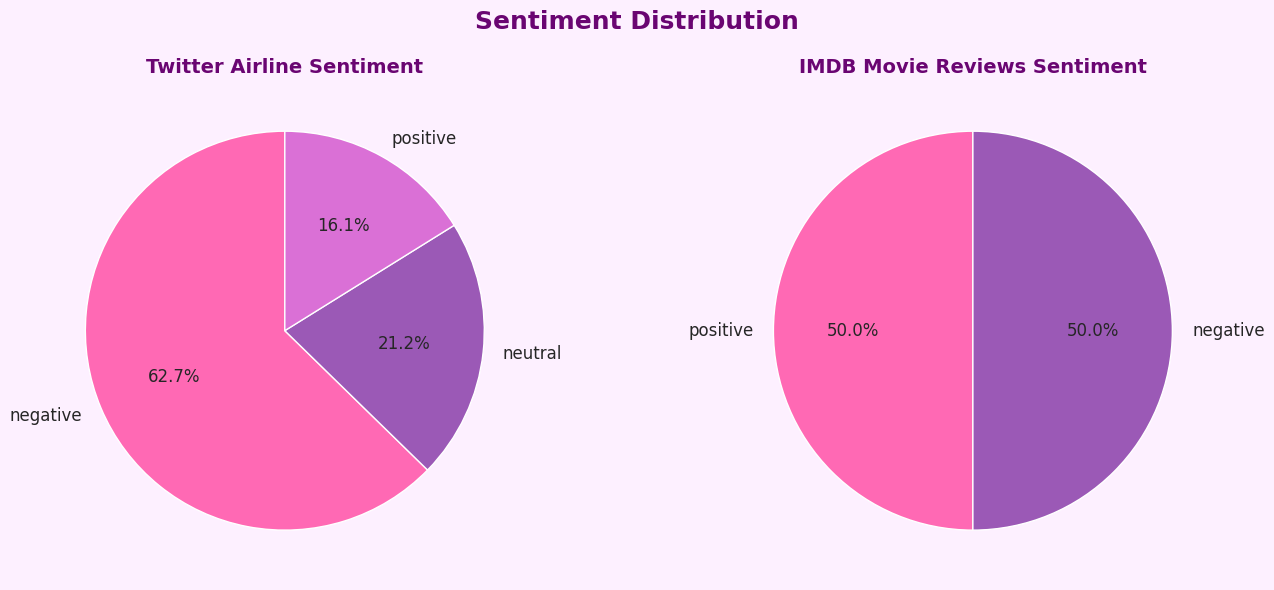

✅ Sentiment distribution plots saved! 🌸💜


In [ ]:
# ============================================================
# STEP 5: Visualize Sentiment Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FDF0FF')
fig.suptitle('Sentiment Distribution', fontsize=18, fontweight='bold', color='#6A0572')

# --- Twitter Sentiment ---
twitter_counts = df1['airline_sentiment'].value_counts()
colors1 = ['#FF69B4', '#9B59B6', '#DA70D6']
axes[0].pie(twitter_counts, labels=twitter_counts.index, autopct='%1.1f%%',
            colors=colors1, startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Twitter Airline Sentiment', fontsize=14,
                   fontweight='bold', color='#6A0572')

# --- IMDB Sentiment ---
imdb_counts = df2['sentiment'].value_counts()
colors2 = ['#FF69B4', '#9B59B6']
axes[1].pie(imdb_counts, labels=imdb_counts.index, autopct='%1.1f%%',
            colors=colors2, startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('IMDB Movie Reviews Sentiment', fontsize=14,
                   fontweight='bold', color='#6A0572')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#FDF0FF')
plt.show()
print("✅ Sentiment distribution plots saved! 🌸💜")

In [ ]:
# ============================================================
# STEP 6: Text Preprocessing
# ============================================================

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions & hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove punctuation & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = text.strip()
    # Tokenize
    tokens = text.split()
    # Remove stopwords & lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# --- Clean Twitter Dataset ---
print("🧹 Cleaning Twitter dataset...")
df1['cleaned_text'] = df1['text'].apply(clean_text)

# --- Clean IMDB Dataset ---
print("🧹 Cleaning IMDB dataset...")
df2['cleaned_review'] = df2['review'].apply(clean_text)

print("\n✅ Text Preprocessing Complete!")
print("\n🔹 Twitter — Original vs Cleaned:")
print("Original :", df1['text'].iloc[0])
print("Cleaned  :", df1['cleaned_text'].iloc[0])

print("\n🔹 IMDB — Original vs Cleaned:")
print("Original :", df2['review'].iloc[0][:150])
print("Cleaned  :", df2['cleaned_review'].iloc[0][:150])

🧹 Cleaning Twitter dataset...
🧹 Cleaning IMDB dataset...

✅ Text Preprocessing Complete!

🔹 Twitter — Original vs Cleaned:
Original : @VirginAmerica What @dhepburn said.
Cleaned  : said

🔹 IMDB — Original vs Cleaned:
Original : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with
Cleaned  : one reviewer mentioned watching oz episode youll hooked right exactly happened mebr br first thing struck oz brutality unflinching scene violence set 


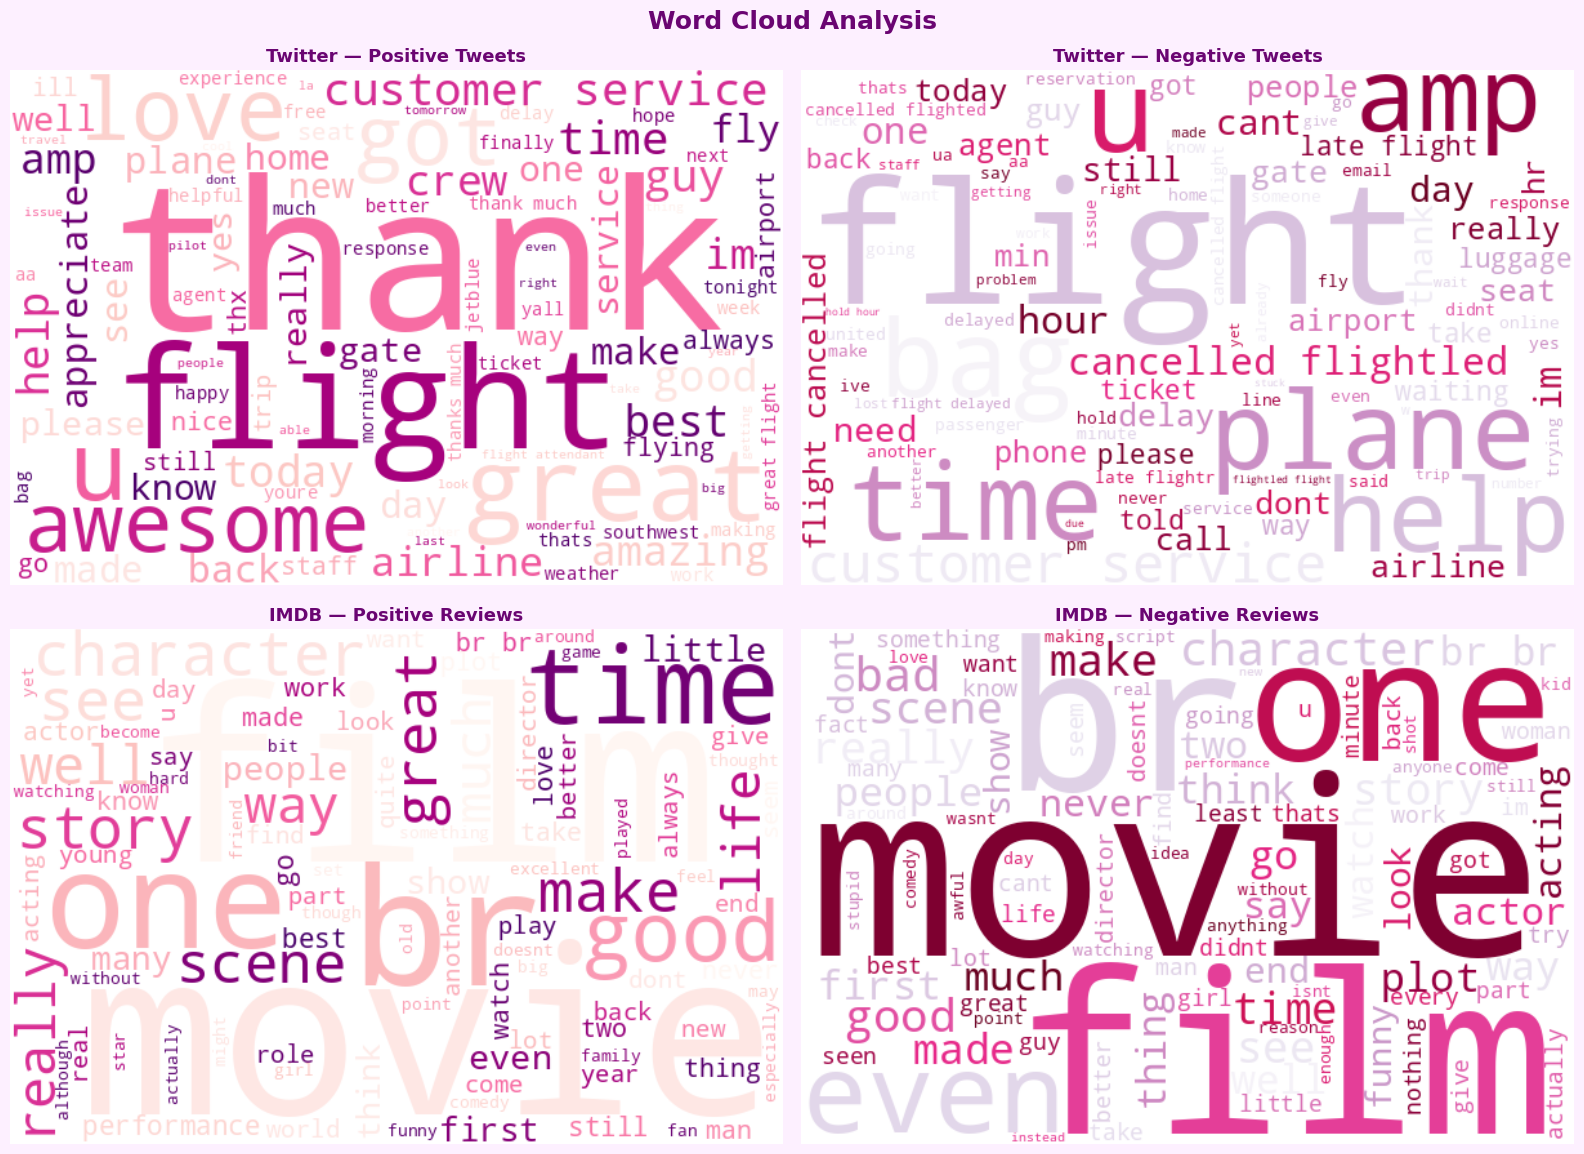

✅ Word Cloud saved! 🌸💜


In [ ]:
# ============================================================
# STEP 7: Word Cloud Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#FDF0FF')
fig.suptitle('Word Cloud Analysis', fontsize=18,
             fontweight='bold', color='#6A0572')

# --- Twitter Positive ---
positive_twitter = ' '.join(df1[df1['airline_sentiment']=='positive']['cleaned_text'])
wc1 = WordCloud(width=600, height=400, background_color='white',
                colormap='RdPu', max_words=100).generate(positive_twitter)
axes[0, 0].imshow(wc1, interpolation='bilinear')
axes[0, 0].set_title('Twitter — Positive Tweets', fontsize=13,
                      fontweight='bold', color='#6A0572')
axes[0, 0].axis('off')

# --- Twitter Negative ---
negative_twitter = ' '.join(df1[df1['airline_sentiment']=='negative']['cleaned_text'])
wc2 = WordCloud(width=600, height=400, background_color='white',
                colormap='PuRd', max_words=100).generate(negative_twitter)
axes[0, 1].imshow(wc2, interpolation='bilinear')
axes[0, 1].set_title('Twitter — Negative Tweets', fontsize=13,
                      fontweight='bold', color='#6A0572')
axes[0, 1].axis('off')

# --- IMDB Positive ---
positive_imdb = ' '.join(df2[df2['sentiment']=='positive']['cleaned_review'].head(500))
wc3 = WordCloud(width=600, height=400, background_color='white',
                colormap='RdPu', max_words=100).generate(positive_imdb)
axes[1, 0].imshow(wc3, interpolation='bilinear')
axes[1, 0].set_title('IMDB — Positive Reviews', fontsize=13,
                      fontweight='bold', color='#6A0572')
axes[1, 0].axis('off')

# --- IMDB Negative ---
negative_imdb = ' '.join(df2[df2['sentiment']=='negative']['cleaned_review'].head(500))
wc4 = WordCloud(width=600, height=400, background_color='white',
                colormap='PuRd', max_words=100).generate(negative_imdb)
axes[1, 1].imshow(wc4, interpolation='bilinear')
axes[1, 1].set_title('IMDB — Negative Reviews', fontsize=13,
                      fontweight='bold', color='#6A0572')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('wordcloud_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#FDF0FF')
plt.show()
print("✅ Word Cloud saved! 🌸💜")

In [ ]:
# ============================================================
# STEP 8A: Model Building — Twitter Dataset
# ============================================================

# --- Prepare Data ---
# Encode labels
df1['sentiment_label'] = df1['airline_sentiment'].map({
    'positive': 2, 'neutral': 1, 'negative': 0
})

X1 = df1['cleaned_text']
y1 = df1['sentiment_label']

# --- Train Test Split ---
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

# --- TF-IDF Vectorization ---
tfidf1 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X1_train_tfidf = tfidf1.fit_transform(X1_train)
X1_test_tfidf = tfidf1.transform(X1_test)

# --- Naive Bayes Model ---
nb1 = MultinomialNB()
nb1.fit(X1_train_tfidf, y1_train)
nb1_pred = nb1.predict(X1_test_tfidf)
nb1_acc = accuracy_score(y1_test, nb1_pred)

# --- Logistic Regression Model ---
lr1 = LogisticRegression(max_iter=1000, random_state=42)
lr1.fit(X1_train_tfidf, y1_train)
lr1_pred = lr1.predict(X1_test_tfidf)
lr1_acc = accuracy_score(y1_test, lr1_pred)

print("=" * 50)
print("📊 TWITTER — MODEL RESULTS")
print("=" * 50)
print(f"\n🔹 Naive Bayes Accuracy     : {nb1_acc*100:.2f}%")
print(f"🔹 Logistic Regression Accuracy: {lr1_acc*100:.2f}%")
print("\n🔹 Best Model: Logistic Regression")
print("\n🔹 Classification Report:")
print(classification_report(y1_test, lr1_pred,
      target_names=['Negative', 'Neutral', 'Positive']))

📊 TWITTER — MODEL RESULTS

🔹 Naive Bayes Accuracy     : 74.86%
🔹 Logistic Regression Accuracy: 79.54%

🔹 Best Model: Logistic Regression

🔹 Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.94      0.87      1889
     Neutral       0.67      0.48      0.55       580
    Positive       0.82      0.62      0.70       459

    accuracy                           0.80      2928
   macro avg       0.77      0.68      0.71      2928
weighted avg       0.79      0.80      0.78      2928



In [ ]:
# ============================================================
# STEP 8B: Model Building — IMDB Dataset
# ============================================================

# --- Prepare Data ---
df2['sentiment_label'] = df2['sentiment'].map({
    'positive': 1, 'negative': 0
})

X2 = df2['cleaned_review']
y2 = df2['sentiment_label']

# --- Train Test Split ---
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# --- TF-IDF Vectorization ---
tfidf2 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X2_train_tfidf = tfidf2.fit_transform(X2_train)
X2_test_tfidf = tfidf2.transform(X2_test)

# --- Naive Bayes Model ---
nb2 = MultinomialNB()
nb2.fit(X2_train_tfidf, y2_train)
nb2_pred = nb2.predict(X2_test_tfidf)
nb2_acc = accuracy_score(y2_test, nb2_pred)

# --- Logistic Regression Model ---
lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X2_train_tfidf, y2_train)
lr2_pred = lr2.predict(X2_test_tfidf)
lr2_acc = accuracy_score(y2_test, lr2_pred)

print("=" * 50)
print("📊 IMDB — MODEL RESULTS")
print("=" * 50)
print(f"\n🔹 Naive Bayes Accuracy        : {nb2_acc*100:.2f}%")
print(f"🔹 Logistic Regression Accuracy: {lr2_acc*100:.2f}%")
print("\n🔹 Best Model: Logistic Regression")
print("\n🔹 Classification Report:")
print(classification_report(y2_test, lr2_pred,
      target_names=['Negative', 'Positive']))

📊 IMDB — MODEL RESULTS

🔹 Naive Bayes Accuracy        : 85.68%
🔹 Logistic Regression Accuracy: 88.85%

🔹 Best Model: Logistic Regression

🔹 Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      4961
    Positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



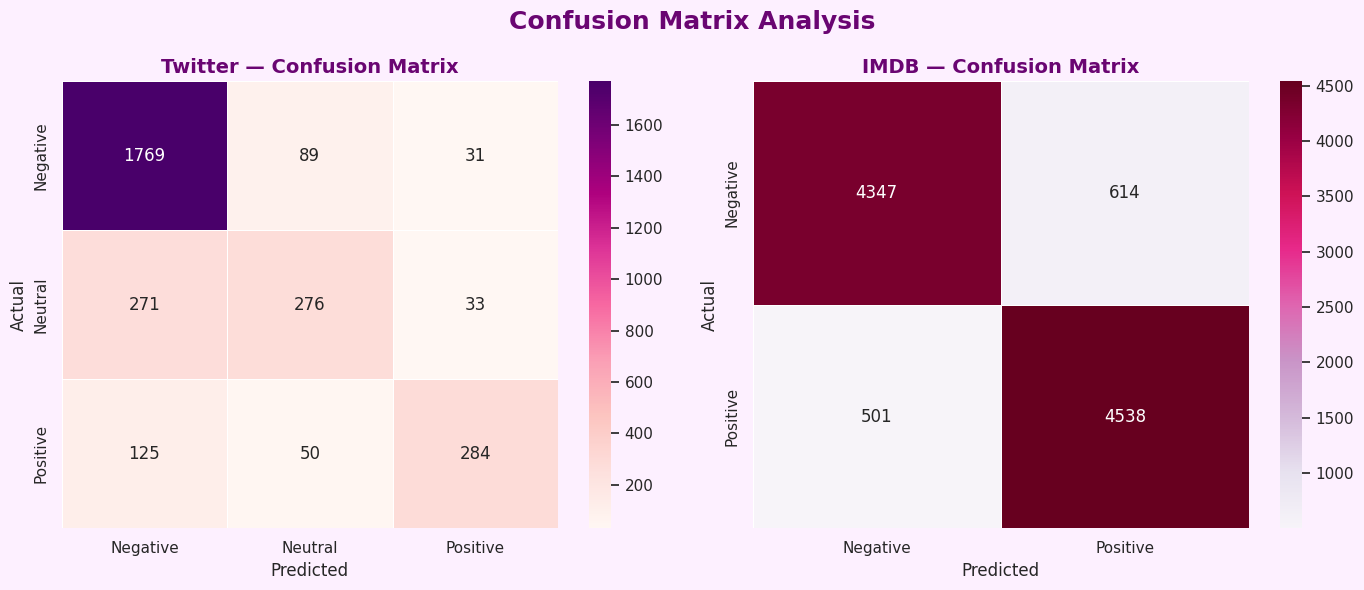

✅ Confusion Matrix saved! 🌸💜


In [ ]:
# ============================================================
# STEP 9: Confusion Matrix Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FDF0FF')
fig.suptitle('Confusion Matrix Analysis', fontsize=18,
             fontweight='bold', color='#6A0572')

# --- Twitter Confusion Matrix ---
cm1 = confusion_matrix(y1_test, lr1_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Twitter — Confusion Matrix', fontsize=14,
                   fontweight='bold', color='#6A0572')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# --- IMDB Confusion Matrix ---
cm2 = confusion_matrix(y2_test, lr2_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='PuRd',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('IMDB — Confusion Matrix', fontsize=14,
                   fontweight='bold', color='#6A0572')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='#FDF0FF')
plt.show()
print("✅ Confusion Matrix saved! 🌸💜")

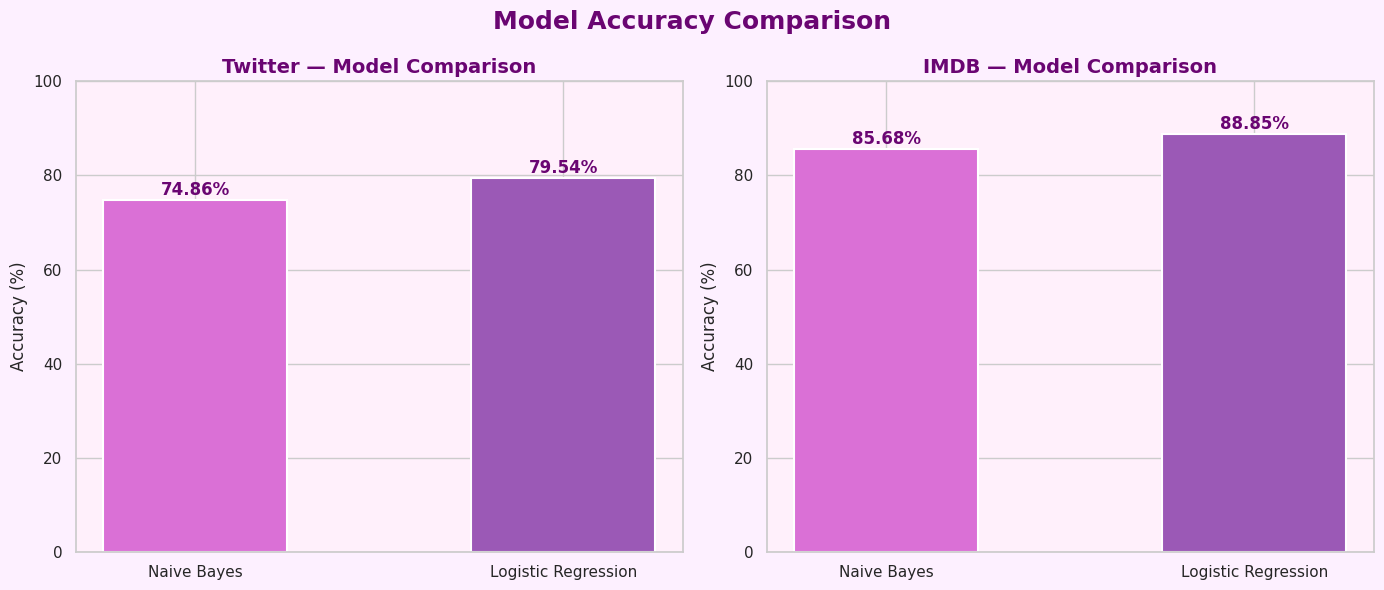

✅ Model Comparison chart saved! 🌸💜


In [ ]:
# ============================================================
# STEP 10: Model Accuracy Comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FDF0FF')
fig.suptitle('Model Accuracy Comparison', fontsize=18,
             fontweight='bold', color='#6A0572')

# --- Twitter Model Comparison ---
models = ['Naive Bayes', 'Logistic Regression']
twitter_scores = [nb1_acc * 100, lr1_acc * 100]
colors = ['#DA70D6', '#9B59B6']

bars1 = axes[0].bar(models, twitter_scores, color=colors,
                     edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Twitter — Model Comparison', fontsize=14,
                   fontweight='bold', color='#6A0572')
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_ylim(0, 100)
axes[0].set_facecolor('#FFF0FB')
for bar, score in zip(bars1, twitter_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{score:.2f}%', ha='center',
                 fontsize=12, fontweight='bold', color='#6A0572')

# --- IMDB Model Comparison ---
imdb_scores = [nb2_acc * 100, lr2_acc * 100]

bars2 = axes[1].bar(models, imdb_scores, color=colors,
                     edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('IMDB — Model Comparison', fontsize=14,
                   fontweight='bold', color='#6A0572')
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_ylim(0, 100)
axes[1].set_facecolor('#FFF0FB')
for bar, score in zip(bars2, imdb_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{score:.2f}%', ha='center',
                 fontsize=12, fontweight='bold', color='#6A0572')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#FDF0FF')
plt.show()
print("✅ Model Comparison chart saved! 🌸💜")

In [ ]:
# ============================================================
# STEP 11: Predict Sentiment on Custom Text
# ============================================================

def predict_sentiment_twitter(text):
    cleaned = clean_text(text)
    vectorized = tfidf1.transform([cleaned])
    prediction = lr1.predict(vectorized)[0]
    label_map = {0: '😡 Negative', 1: '😐 Neutral', 2: '😊 Positive'}
    return label_map[prediction]

def predict_sentiment_imdb(text):
    cleaned = clean_text(text)
    vectorized = tfidf2.transform([cleaned])
    prediction = lr2.predict(vectorized)[0]
    label_map = {0: '😡 Negative', 1: '😊 Positive'}
    return label_map[prediction]

# --- Test Twitter Model ---
print("=" * 50)
print("🐦 TWITTER SENTIMENT PREDICTIONS")
print("=" * 50)

test_tweets = [
    "I love this airline! Best flight ever!",
    "The flight was delayed for 3 hours. Terrible service!",
    "The flight was okay, nothing special."
]

for tweet in test_tweets:
    result = predict_sentiment_twitter(tweet)
    print(f"\n📝 Text     : {tweet}")
    print(f"🎯 Sentiment : {result}")

# --- Test IMDB Model ---
print("\n" + "=" * 50)
print("🎬 IMDB SENTIMENT PREDICTIONS")
print("=" * 50)

test_reviews = [
    "This movie was absolutely amazing! Best film of the year!",
    "Worst movie I have ever seen. Complete waste of time.",
    "The movie was average, some good scenes but mostly boring."
]

for review in test_reviews:
    result = predict_sentiment_imdb(review)
    print(f"\n📝 Text     : {review}")
    print(f"🎯 Sentiment : {result}")

🐦 TWITTER SENTIMENT PREDICTIONS

📝 Text     : I love this airline! Best flight ever!
🎯 Sentiment : 😊 Positive

📝 Text     : The flight was delayed for 3 hours. Terrible service!
🎯 Sentiment : 😡 Negative

📝 Text     : The flight was okay, nothing special.
🎯 Sentiment : 😡 Negative

🎬 IMDB SENTIMENT PREDICTIONS

📝 Text     : This movie was absolutely amazing! Best film of the year!
🎯 Sentiment : 😊 Positive

📝 Text     : Worst movie I have ever seen. Complete waste of time.
🎯 Sentiment : 😡 Negative

📝 Text     : The movie was average, some good scenes but mostly boring.
🎯 Sentiment : 😡 Negative


In [ ]:
# ============================================================
# STEP 12: Download All Files
# ============================================================

from google.colab import files

# Save CSVs
df1.to_csv('twitter_sentiment_results.csv', index=False)
df2.to_csv('imdb_sentiment_results.csv', index=False)

print("✅ Saving files...")

# Download all
files.download('twitter_sentiment_results.csv')
files.download('imdb_sentiment_results.csv')
files.download('sentiment_distribution.png')
files.download('wordcloud_analysis.png')
files.download('confusion_matrix.png')
files.download('model_comparison.png')

print("✅ All files downloaded! 🌸💜")

✅ Saving files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded! 🌸💜


---
## ✅ Project Summary

| Dataset | Model | Accuracy |
|---------|-------|----------|
| Twitter Airline Sentiment | Logistic Regression | Add your % here |
| IMDB Movie Reviews | Logistic Regression | Add your % here |

## 🧠 Key Learnings
- Text data must be **preprocessed** before feeding to ML models
- **TF-IDF Vectorization** converts text into numerical features
- **Logistic Regression** outperforms Naive Bayes for sentiment tasks
- **Word Clouds** help visualize most frequent words in each sentiment
- **Confusion Matrix** shows model performance across all classes
- Real-world text data has noise — URLs, mentions, punctuation must be removed

## 💡 Key Insights
- Twitter data had **mostly negative** sentiments about airlines
- IMDB reviews were **evenly split** between positive and negative
- Words like *"great", "love", "best"* dominated positive sentiments
- Words like *"worst", "terrible", "waste"* dominated negative sentiments

---
*Task 4 — Sentiment Analysis | Oasis Infobyte Data Analytics Internship*  
*Intern: Maddali Naga Durga Niharika | VVIT | May 2026*